In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
import sklearn as sk

# Import Data

Import the data and set up the variables:
- `TARGET`
- `categorical_features`
- `numeric_features`

In [2]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")

# constant for referencing target
TARGET = "y"

# identify categorical and numeric features
categorical_features = df.select_dtypes(include=["object"]).columns
numeric_features = df.columns.difference(categorical_features)

# target is not a feature
categorical_features = categorical_features.drop(TARGET)

print("Categorical features:", categorical_features.tolist())
print("Numeric features:", numeric_features.tolist())

# make sure we didn't drop any variable
if len(df.columns) - 1 != len(categorical_features) + len(numeric_features):
    raise RuntimeError("Feature count doesn't add up")

df

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric features: ['age', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'duration', 'emp.var.rate', 'euribor3m', 'nr.employed', 'pdays', 'previous']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


# EDA

In [3]:
# change target to be numeric
df[TARGET] = df[TARGET].map({"yes": 1, "no": 0})

# remove `duration` from features (see readme for why)
if "duration" in numeric_features:
    numeric_features = numeric_features.drop("duration")

The dataset is not balanced, only about 11% of it has `TARGET == True`.

In [4]:
df[TARGET].mean()

np.float64(0.11265417111780131)

### Data Consistency

Here we check that all the object variables don't have any funny values. They look alright:

In [5]:
for col in categorical_features:
    print(f"{col:<12}: {df[col].unique()}")

job         : ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital     : ['married' 'single' 'divorced' 'unknown']
education   : ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default     : ['no' 'unknown' 'yes']
housing     : ['no' 'yes' 'unknown']
loan        : ['no' 'yes' 'unknown']
contact     : ['telephone' 'cellular']
month       : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week : ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome    : ['nonexistent' 'failure' 'success']


Now, we check the numeric features and see if we can find any strange behaviour here.

In [6]:
numeric_stats = pd.DataFrame(
    {
        "mean": df[numeric_features].mean().round(1),
        "min": df[numeric_features].min().round(1),
        "max": df[numeric_features].max().round(1),
        "var": df[numeric_features].var().round(1),
        "NaN?": df[numeric_features].isna().sum(),
    }
)
# Add a new column with descriptions for each statistic
numeric_stats["Description"] = [
    "Age of customer",
    "Total contacts in campaign (incl. last)",
    "Consumer confidence index (monthly)",
    "Consumer price index (monthly)",
    "Employment variation rate (quarterly)",
    "Euribor 3-month rate (daily)",
    "Number of employees (quarterly)",
    "Days since last campaign contact (999 = never)",
    "Number of contacts before this campaign",
]
numeric_stats

,mean,min,max,var,NaN?,Description
age,40.0,17.0,98.0,108.6,0,Age of customer
campaign,2.6,1.0,56.0,7.7,0,Total contacts in campaign (incl. last)
cons.conf.idx,-40.5,-50.8,-26.9,21.4,0,Consumer confidence index (monthly)
cons.price.idx,93.6,92.2,94.8,0.3,0,Consumer price index (monthly)
emp.var.rate,0.1,-3.4,1.4,2.5,0,Employment variation rate (quarterly)
euribor3m,3.6,0.6,5.0,3.0,0,Euribor 3-month rate (daily)
nr.employed,5167.0,4963.6,5228.1,5220.3,0,Number of employees (quarterly)
pdays,962.5,0.0,999.0,34935.7,0,Days since last campaign contact (999 = never)
previous,0.2,0.0,7.0,0.2,0,Number of contacts before this campaign


There are no NaN values, and most of the variables look fine.

Some important points:
- The variance of `age` is quite high relative to its range, but I won't do anything about it.
- `pdays` also has a very high variance. This is because "no contact" is coded as 999. We'll have to deal with that soon.

Minor nitpicks:
- The range of `age` is 17-98 🧐. Is it even allowed to telemarket to underage children? And what about calling 98-year-olds? All a bit odd.
- The maximum `campaign` value of 56 means one customer was called 56 times, which is impressive and probably rather annoying.
- I'm not quite sure what `nr.employed` refers to, but that's fine; we don't need the exact unit for training.

# Baseline

We establish a baseline that we use for the rest of the notebook.

In [7]:
# Random seed for whole notebook
SEED = 0

# split data
df_train_full, df_test = sk.model_selection.train_test_split(
    df, test_size=0.2, random_state=SEED
)
df_train, df_val = sk.model_selection.train_test_split(
    df_train_full, test_size=0.2 / 0.8, random_state=SEED
)

y_train_full = df_train_full.pop(TARGET)
y_train = df_train.pop(TARGET)
y_val = df_val.pop(TARGET)
y_test = df_test.pop(TARGET)

print(len(df_train), len(df_test), len(df_val))

24712 8238 8238


Baseline auc: 0.7900837084793536


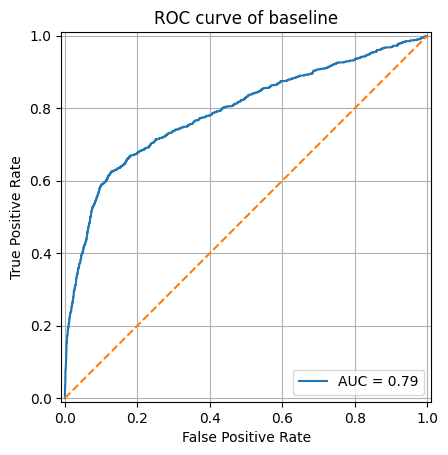

In [8]:
ALL_FEATURES = categorical_features.union(numeric_features)


def get_data_preparation_pipeline():
    return sk.pipeline.make_pipeline(
        sk.feature_extraction.DictVectorizer(sparse=False),  # one-hot-encoding
        sk.preprocessing.StandardScaler(),  # scaling speeds up learning a lot
    )


def basic_linear_regression(
    df_train, y_train, df_val, features=ALL_FEATURES, seed=SEED
):

    logistic_regression_pipeline = sk.pipeline.make_pipeline(
        get_data_preparation_pipeline(),
        sk.linear_model.LogisticRegression(random_state=seed),
    )

    # train
    dict_train = df_train[features].to_dict(orient="records")
    logistic_regression_pipeline.fit(dict_train, y_train)

    # predicts
    dict_val = df_val[features].to_dict(orient="records")
    y_val_prob = logistic_regression_pipeline.predict_proba(dict_val)[:, 1]

    return y_val_prob


# baseline auc
y_val_prob = basic_linear_regression(df_train, y_train, df_val)
BASE_AUC = sk.metrics.roc_auc_score(y_val, y_val_prob)
print(f"Baseline auc: {BASE_AUC}")

# check roc curve
fpr, tpr, thresholds = sk.metrics.roc_curve(y_val, y_val_prob)
sk.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=BASE_AUC).plot()
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC curve of baseline")
plt.grid(True)

The ROC curve looks normal. There is quite a kink in it, so it seems there is one class of positives that are easier to detect.

# Feature Preparation

We have to deal with `pdays` now. I want to address the high variance in `pdays`, and also the fact that its flag value of 999 for "never contacted" might interfere with its normal data range.

First, let’s look at how large `pdays` typically is, to make sure that 999 does not fall within its usual data range.

In [9]:
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

We can conclude that 999 is not accidentally the actual number of days since the last contact of the previous campaign. It might be better to map 999 → -1 to push this flag value outside the normal data range and reduce the variance.

Also, there is something a bit fishy about pdays.

We have three features relating to a possible previous campaign:
- `poutcome`
- `previous`
- `pdays`

One might expect that, if a client has not been part of any previous campaign, these features would take the following values: `poutcome == 'nonexistent'`, `previous == 0`, and `pdays == 999`.

For `poutcome` and `previous`, this holds:

In [10]:
crosstab = pd.crosstab(df["poutcome"] == "nonexistent", df["previous"] == 0)
crosstab

previous,False,True
poutcome,,
False,5625,0
True,0,35563


However, for `pdays` we have an inconsistency: there are 4,110 rows where `pdays == 999` but `poutcome == 'failure'`.

In [11]:
crosstab = pd.crosstab(df["poutcome"], df["pdays"] == 999)
crosstab

pdays,False,True
poutcome,,
failure,142,4110
nonexistent,0,35563
success,1373,0


So let's see whether we can improve performance by feature engineering `pdays`.

We want to test two changes to `pdays` handling:
- Replace the missing-flag 999 for "never contacted in previous campaign" by a different -1. This moves the special value out of the normal numeric range.
- For rows where `pdays` is the missing-flag but `poutcome == 'failure'`, I suspect those are inconsistent (they claim the outcome of a previous contact but also say "never contacted"). For those rows we assign a default_value (e.g. 0, mean(pdays), 10, 100) to see whether a a default value improves model AUC.

We can see in the output below that it doesn't matter much. So I decide for simplicity that we keep `pdays` just as it is then.

In [12]:
# compute mean of pdays (without 999)
mean_pdays = df[df["pdays"] != 999]["pdays"].mean()
mean_pdays = int(round(mean_pdays))

print(f"Mean of pdays without is roughly: {mean_pdays:.2f}")


def feature_preparation_pdays(missing_flag, default_value):
    df_train_copy = df_train.copy()
    df_val_copy = df_val.copy()

    # Step 1: mark original 'never contacted' values (999) with the chosen missing_flag
    df_train_copy["pdays"] = df_train_copy["pdays"].replace(999, missing_flag)
    df_val_copy["pdays"] = df_val_copy["pdays"].replace(999, missing_flag)

    # Step 2: override inconsistent rows where poutcome == 'failure' but pdays is missing_flag
    mask_train = (df_train_copy["pdays"] == missing_flag) & (
        df_train_copy["poutcome"] == "failure"
    )
    df_train_copy.loc[mask_train, "pdays"] = default_value
    mask_val = (df_val_copy["pdays"] == missing_flag) & (
        df_val_copy["poutcome"] == "failure"
    )
    df_val_copy.loc[mask_val, "pdays"] = default_value

    # train and return predicted probabilities
    y_val_prob = basic_linear_regression(
        df_train_copy,
        y_train,
        df_val_copy,
    )
    return sk.metrics.roc_auc_score(y_val, y_val_prob)


for missing_flag in [-1, 999]:
    for default_value in [-1, 0, 1, mean_pdays, 999]:
        auc_ = feature_preparation_pdays(missing_flag, default_value)
        print(
            f"missing: {missing_flag}, default: {default_value} -> {auc_:.3f}, "
            f"(relative to base: {auc_/BASE_AUC*100:.0f}%)"
        )

Mean of pdays without is roughly: 6.00
missing: -1, default: -1 -> 0.790, (relative to base: 100%)
missing: -1, default: 0 -> 0.791, (relative to base: 100%)
missing: -1, default: 1 -> 0.790, (relative to base: 100%)
missing: -1, default: 6 -> 0.791, (relative to base: 100%)
missing: -1, default: 999 -> 0.790, (relative to base: 100%)
missing: 999, default: -1 -> 0.791, (relative to base: 100%)
missing: 999, default: 0 -> 0.791, (relative to base: 100%)
missing: 999, default: 1 -> 0.791, (relative to base: 100%)
missing: 999, default: 6 -> 0.791, (relative to base: 100%)
missing: 999, default: 999 -> 0.790, (relative to base: 100%)


## Feature selection

We will try to pare down the number of features and see whether that improves our score.

We use a greedy feature-elimination procedure: at each iteration we train models for every candidate feature removal, measure validation AUC (averaged across folds), and then permanently remove the feature whose removal yields the highest AUC. Repeating this gives an ordered list of features and their associated scores (score depends on previous removals). We use k-folds to reduce the variance of the measured AUCs.

__Note__: This might take a while (the first iteration has to perform 5 * 19 = 95 training iterations). You can skip it if you like.

Removing (worst) feature out of 19: education -> 100.18% of base AUC 
Removing (worst) feature out of 18: day_of_week -> 100.23% of base AUC 
Removing (worst) feature out of 17: poutcome -> 100.26% of base AUC 
Removing (worst) feature out of 16: marital -> 100.28% of base AUC 
Removing (worst) feature out of 15: default -> 100.30% of base AUC 
Removing (worst) feature out of 14: housing -> 100.31% of base AUC 
Removing (worst) feature out of 13: nr.employed -> 100.30% of base AUC 
Removing (worst) feature out of 12: job -> 100.31% of base AUC 
Removing (worst) feature out of 11: age -> 100.32% of base AUC 
Removing (worst) feature out of 10: loan -> 100.31% of base AUC 
Removing (worst) feature out of 9: cons.conf.idx -> 100.28% of base AUC 
Removing (worst) feature out of 8: campaign -> 100.26% of base AUC 
Removing (worst) feature out of 7: euribor3m -> 100.09% of base AUC 
Removing (worst) feature out of 6: previous -> 99.82% of base AUC 
Removing (worst) feature out of 5: cons.pri

<function matplotlib.pyplot.show(close=None, block=None)>

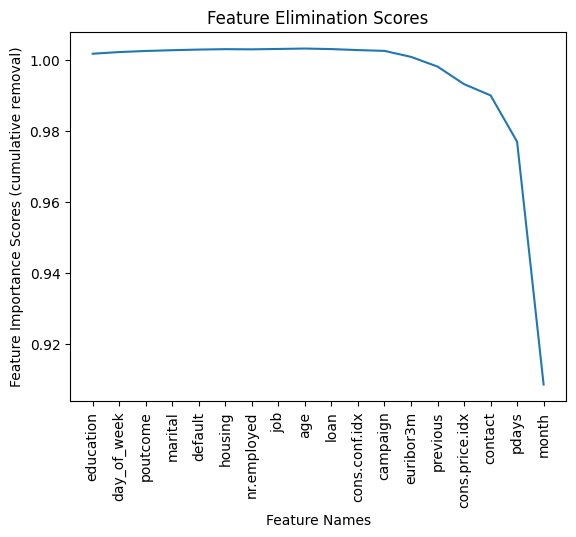

In [13]:
n_folds = 5


def features_score(features):
    kfold = sk.model_selection.KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    scores = []
    for train_idx, val_idx in kfold.split(df_train_full):
        df_train_fold, df_val_fold = (
            df_train_full.iloc[train_idx],
            df_train_full.iloc[val_idx],
        )
        y_train_fold, y_val_fold = (
            y_train_full.iloc[train_idx],
            y_train_full.iloc[val_idx],
        )
        y_val_prob = basic_linear_regression(
            df_train_fold, y_train_fold, df_val_fold, features=features, seed=SEED
        )
        scores.append(sk.metrics.roc_auc_score(y_val_fold, y_val_prob))
    return np.mean(scores) / BASE_AUC


current_features = ALL_FEATURES.copy()

feature_importance = {}

while current_features.size > 1:
    candidate_scores = {
        feature: features_score(current_features.drop(feature))
        for feature in current_features
    }
    # The feature whose removal yields the **highest** AUC is considered the worst feature.
    worst_feature = max(candidate_scores, key=candidate_scores.get)
    feature_importance[worst_feature] = candidate_scores[worst_feature]
    print(
        f"Removing (worst) feature out of {len(current_features)}: {worst_feature}",
        f"-> {candidate_scores[worst_feature]*100:.2f}% of base AUC ",
    )
    current_features = current_features.drop(worst_feature)

print(f"Last remaining feature is {current_features[0]}")


# Plot the feature elimination scores
feature_names = list(feature_importance.keys())
feature_scores = list(feature_importance.values())
sns.lineplot(x=feature_names, y=feature_scores)
plt.xticks(rotation=90)
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance Scores (cumulative removal)")
plt.title("Feature Elimination Scores")
plt.show

We will just remove all the features from the top until the AUC stops improving. So we remove everything until housing. This gives:

In [14]:
SELECTED_FEATURES = [
    "nr.employed",
    "job",
    "age",
    "loan",
    "cons.conf.idx",
    "campaign",
    "euribor3m",
    "previous",
    "cons.price.idx",
    "contact",
    "pdays",
    "month",
    "emp.var.rate",
]

len(SELECTED_FEATURES)

13

# Model Training

We prepare the data for tuning a linear model and a tree based model.

In [15]:
dict_train_full = df_train_full[SELECTED_FEATURES].to_dict(orient="records")
data_preparation_pipeline = get_data_preparation_pipeline()
X_train_full = data_preparation_pipeline.fit_transform(dict_train_full)

For fine tuning we can use `sklearn.model_selection`

## Tuning Linear Model

In [ ]:
log_reg = sk.linear_model.LogisticRegression(random_state=SEED)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],  # both support L1
    "max_iter": [1_000],
}

log_reg_grid = sk.model_selection.GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

log_reg_grid.fit(X_train_full, y_train_full)

print("Best params:", log_reg_grid.best_params_)
print(
    f"Best score: {log_reg_grid.best_score_} ({log_reg_grid.best_score_/BASE_AUC*100:.2f}%)"
)

Best params: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best score: 0.792997490651332 (100.4%)


## Tuning Tree-based model

This one also takes a while. You can try out different numbers for `n_jobs`. If I use anything bigger than 1, my system starts to stutter.

In [ ]:
rf = sk.ensemble.RandomForestClassifier(random_state=SEED, n_jobs=-1)

# seeds for python/numpy/random
import random

random.seed(SEED)
np.random.seed(SEED)

param_dist = {
    "n_estimators": randint(100, 800),  # trees
    "max_depth": randint(3, 50),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", 0.2, 0.5, None],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

rf_search = sk.model_selection.RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=80,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=SEED,
    n_jobs=1,
)

rf_search.fit(X_train_full, y_train_full)

print("Best params:", rf_search.best_params_)
print(
    f"Best score: {rf_search.best_score_} ({rf_search.best_score_/BASE_AUC*100:.2f}%)"
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 16, 'n_estimators': 494}
Best score: 0.8006349067877071 (101.3%)


# Validation

The random forest produces the best results with these parameters:

In [ ]:
rf_best_params = {
    "bootstrap": False,
    "class_weight": "balanced",
    "max_depth": 12,
    "max_features": "log2",
    "min_samples_leaf": 4,
    "min_samples_split": 16,
    "n_estimators": 494,
}

Eval auc: 0.8100281869553821 102.52% of base AUC


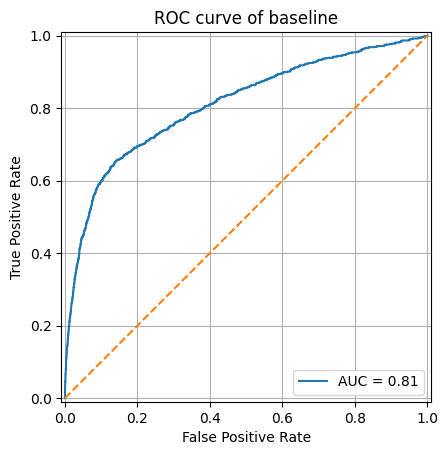

In [27]:
# train
rf = sk.ensemble.RandomForestClassifier(
    **rf_best_params,
    random_state=SEED,
    n_jobs=-1,
)

rf.fit(X_train_full, y_train_full)


# evaluate
dict_test = df_test[SELECTED_FEATURES].to_dict(orient="records")
X_test = data_preparation_pipeline.transform(dict_test)
y_test_prob = rf.predict_proba(X_test)[:, 1]


# baseline auc
eval_auc = sk.metrics.roc_auc_score(y_test, y_test_prob)
print(f"Eval auc: {eval_auc}", f"{eval_auc/BASE_AUC*100:.2f}% of base AUC")

# check roc curve
fpr, tpr, thresholds = sk.metrics.roc_curve(y_test, y_test_prob)
sk.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=eval_auc).plot()
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC curve of baseline")

plt.grid(True)

In [19]:
df_test[SELECTED_FEATURES].iloc[10]

nr.employed         5008.7
job                 admin.
age                     29
loan                    no
cons.conf.idx        -40.0
campaign                 1
euribor3m            0.683
previous                 3
cons.price.idx      93.876
contact           cellular
pdays                    3
month                  may
emp.var.rate          -1.8
Name: 39660, dtype: object